In [9]:
import pandas as pd

# قراءة البيانات (تأكد أن اسم الملف مطابق لما هو موجود في اليسار: sales.csv)
df = pd.read_csv('sales.csv')

# عرض أول 5 أسطر بشكل أنيق
df.head()

,_id,PropertyID,PropType,taxkey,Address,CondoProject,District,nbhd,Style,Extwall,...,Rooms,FinishedSqft,SoldAsVacantLand,Units,Bdrms,Fbath,Hbath,Lotsize,Sale_date,Sale_price
0,1,98689,Condominium,70010000,"9170 N 70TH ST, Unit 5",NORTHRIDGE WOOD LAKE,9,5010,Condo Townhouse,NaN,...,6.0,1244.0,N,1,3.0,2,1,0,6/26/2025,150000
1,2,98739,Condominium,70060000,"9276 N 70TH ST, Unit 3",NORTHRIDGE WOOD LAKE,9,5010,Condo Townhouse,NaN,...,7.0,1437.0,N,1,4.0,2,1,0,6/10/2025,160000
2,3,98800,Condominium,70121000,"6903 W GLENBROOK RD, Unit 2",NORTHRIDGE WOOD LAKE,9,5010,Condo Townhouse,NaN,...,6.0,1244.0,N,1,3.0,2,1,0,6/2/2025,145000
3,4,98974,Condominium,310418000,"9002 N 70TH ST, Unit 5",NORTHRIDGE THE TREES,9,5030,Condo Townhouse,NaN,...,5.0,1268.0,N,1,3.0,1,1,0,3/18/2025,139900
4,5,102690,Commercial,769996112,11919 W BRADLEY RD,NaN,9,6202,Religious Institution,NaN,...,NaN,19284.0,N,1,NaN,0,0,0,3/21/2025,2000000


In [10]:
# كود التشخيص
print(df.columns.tolist())

['_id', 'PropertyID', 'PropType', 'taxkey', 'Address', 'CondoProject', 'District', 'nbhd', 'Style', 'Extwall', 'Stories', 'Year_Built', 'Rooms', 'FinishedSqft', 'SoldAsVacantLand', 'Units', 'Bdrms', 'Fbath', 'Hbath', 'Lotsize', 'Sale_date', 'Sale_price']


In [11]:
# 1. تحويل التاريخ إلى صيغة مفهومة لبايثون (إذا وجد عمود للتاريخ)
# سنفترض وجود عمود اسمه 'Sale_Date'
if 'Sale_date' in df.columns:
    df['Sale_date'] = pd.to_datetime(df['Sale_date'])

# 2. استبعاد الأسعار غير المنطقية (مثلاً أقل من 10,000 دولار)
# في العقارات، الأسعار المنخفضة جداً غالباً ما تكون أخطاء إدخال أو نقل ملكية رمزي
df_clean = df[df['Sale_price'] > 10000].copy()

# 3. عرض ملخص إحصائي سريع للأسعار
print("--- ملخص أسعار العقارات في ميلووكي ---")
print(df_clean['Sale_price'].describe())

--- ملخص أسعار العقارات في ميلووكي ---
count    1.761000e+03
mean     2.805937e+05
std      4.958303e+05
min      2.900000e+04
25%      1.560000e+05
50%      2.300000e+05
75%      3.050000e+05
max      1.680000e+07
Name: Sale_price, dtype: float64


In [12]:
print(f"لدينا {df.shape[0]} سجل بيع في ميلووكي.")
print(f"وعدد الخصائص (الأعمدة) هو {df.shape[1]}.")

لدينا 1762 سجل بيع في ميلووكي.
وعدد الخصائص (الأعمدة) هو 22.


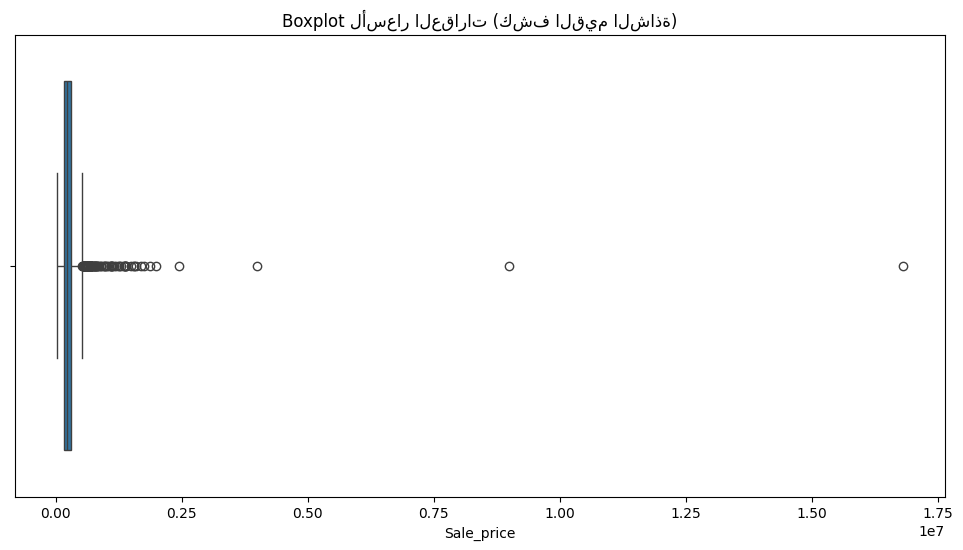

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_clean['Sale_price'])
plt.title('Boxplot لأسعار العقارات (كشف القيم الشاذة)')
plt.show()

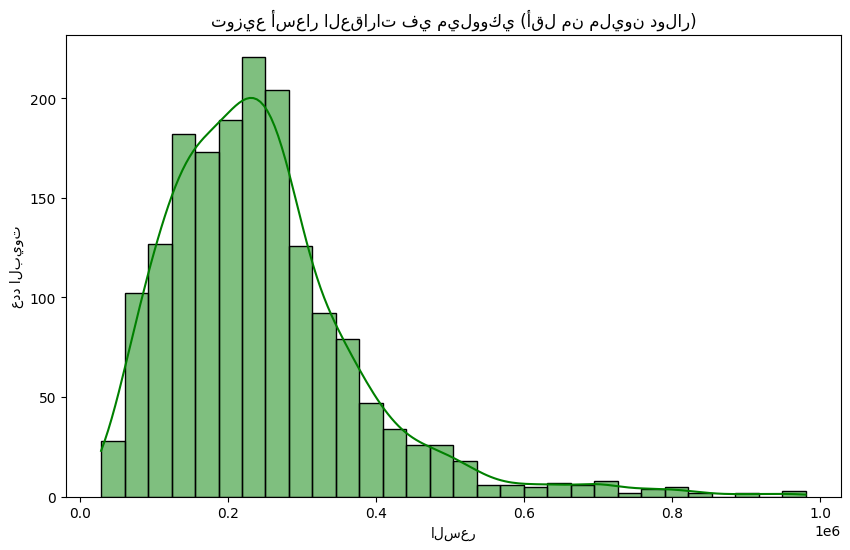

In [14]:
# سنركز فقط على العقارات التي سعرها أقل من مليون دولار 
# لكي نرى توزيع السوق الحقيقي لأغلب الناس
df_final = df_clean[df_clean['Sale_price'] < 1000000]

# الآن لنرسم التوزيع (Histogram) بشكل أوضح
plt.figure(figsize=(10, 6))
sns.histplot(df_final['Sale_price'], bins=30, kde=True, color='green')
plt.title('توزيع أسعار العقارات في ميلووكي (أقل من مليون دولار)')
plt.xlabel('السعر')
plt.ylabel('عدد البيوت')
plt.show()

# milluakee analaizing sales 


--- تحليل المناطق: متوسط السعر وعدد العمليات ---
                   mean  count
District                      
3         372482.539683    126
4         355597.115385    104
14        303713.203125    128
11        286535.176923    130
13        280786.396396    111
10        272239.062500    128
5         231588.514286    175
6         225241.153846    130
8         221306.976744     86
12        210241.654762     84
2         195193.023256     86
9         187117.964602    113
7         177311.311475    122
1         171792.737705    122
15        144014.623529     85


/var/folders/w7/8dpbgf8j0zj728ct7z3qqlc80000gn/T/ipykernel_1308/1870227981.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_analysis.index, y=district_analysis['mean'], palette='viridis')


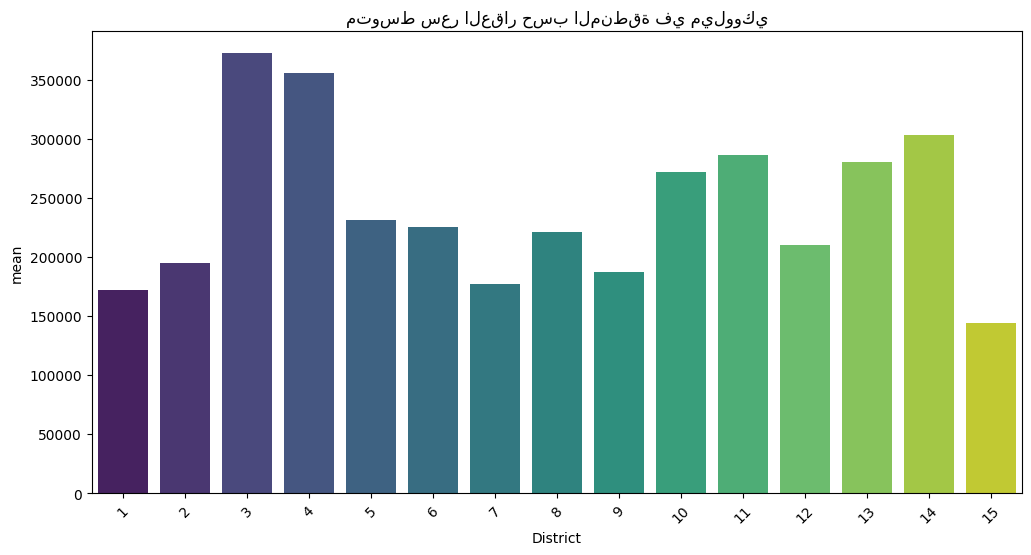

In [15]:
# حساب متوسط السعر لكل منطقة (District)
district_analysis = df_final.groupby('District')['Sale_price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

# عرض النتائج
print("--- تحليل المناطق: متوسط السعر وعدد العمليات ---")
print(district_analysis)

# رسمها بيانيًا لرؤية الفرق بين المناطق
plt.figure(figsize=(12, 6))
sns.barplot(x=district_analysis.index, y=district_analysis['mean'], palette='viridis')
plt.xticks(rotation=45)
plt.title('متوسط سعر العقار حسب المنطقة في ميلووكي')
plt.show()

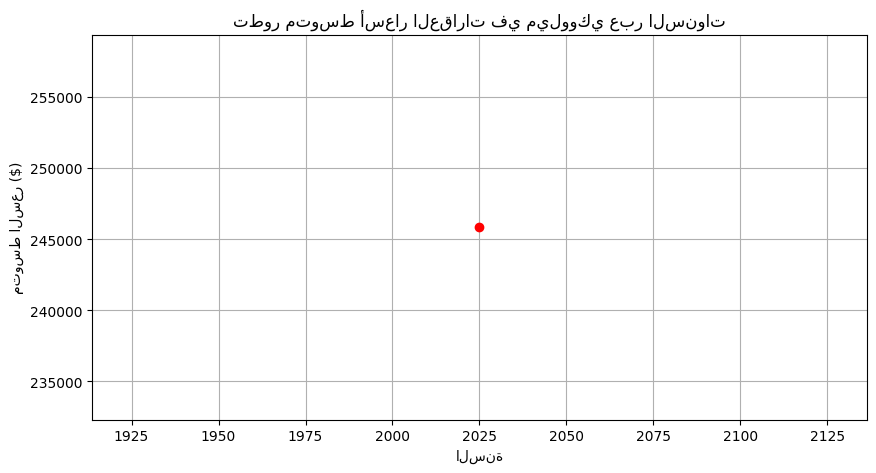

In [16]:
# استخراج السنة من تاريخ البيع (إذا لم يكن لديك عمود للسنة جاهز)
# سنفترض أن العمود اسمه 'Sale_date' أو سنستخدم السنة الموجودة في البيانات
if 'Sale_date' in df_final.columns:
    df_final['Year'] = pd.to_datetime(df_final['Sale_date']).dt.year

# حساب متوسط السعر لكل سنة
yearly_trend = df_final.groupby('Year')['Sale_price'].mean()

# رسم الاتجاه الزمني
plt.figure(figsize=(10, 5))
yearly_trend.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('تطور متوسط أسعار العقارات في ميلووكي عبر السنوات')
plt.xlabel('السنة')
plt.ylabel('متوسط السعر ($)')
plt.grid(True)
plt.show()


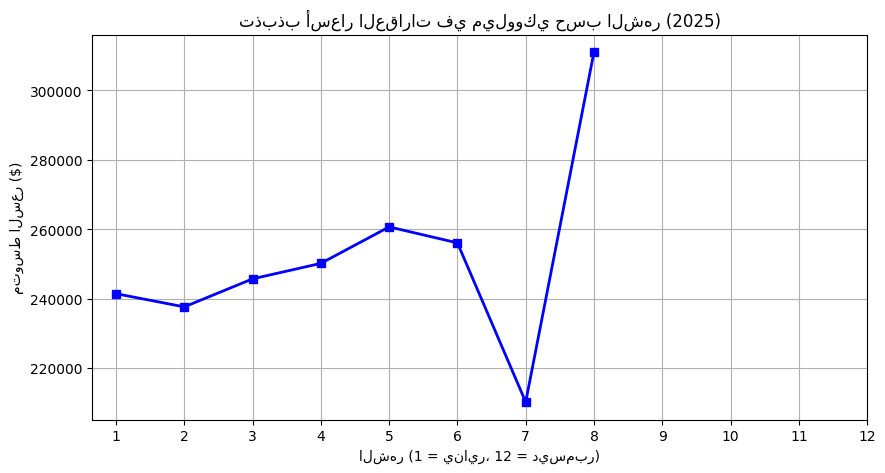

In [17]:
# 1. استخراج الشهر من التاريخ
if 'Sale_date' in df_final.columns:
    df_final['Month'] = pd.to_datetime(df_final['Sale_date']).dt.month

# 2. حساب متوسط السعر لكل شهر
monthly_trend = df_final.groupby('Month')['Sale_price'].mean()

# 3. رسم الاتجاه الشهري
plt.figure(figsize=(10, 5))
monthly_trend.plot(kind='line', marker='s', color='blue', linewidth=2)
plt.title('تذبذب أسعار العقارات في ميلووكي حسب الشهر (2025)')
plt.xlabel('الشهر (1 = يناير، 12 = ديسمبر)')
plt.ylabel('متوسط السعر ($)')
plt.xticks(range(1, 13)) # لإظهار جميع الأشهر
plt.grid(True)
plt.show()

In [18]:
# مقارنة متوسط السعر ومساحة العقار بين شهري 7 و 8
# ملاحظة: استبدل 'Finished_Square_Footage' باسم عمود المساحة في ملفك إذا كان مختلفاً
comparison = df_final[df_final['Month'].isin([7, 8])].groupby('Month')[['Sale_price']].mean()

print("--- مقارنة بين شهر 7 وشهر 8 ---")
print(comparison)

# لنرى نوع العقارات التي بيعت في شهر 8 وجعلت السعر يرتفع
august_data = df_final[df_final['Month'] == 8]
print("\n--- أنواع العقارات المباعة في شهر 8 ---")
print(august_data['PropType'].value_counts())


--- مقارنة بين شهر 7 وشهر 8 ---
          Sale_price
Month               
7      210183.783784
8      311000.000000

--- أنواع العقارات المباعة في شهر 8 ---
PropType
Condominium     1
Lg Apartment    1
Name: count, dtype: int64


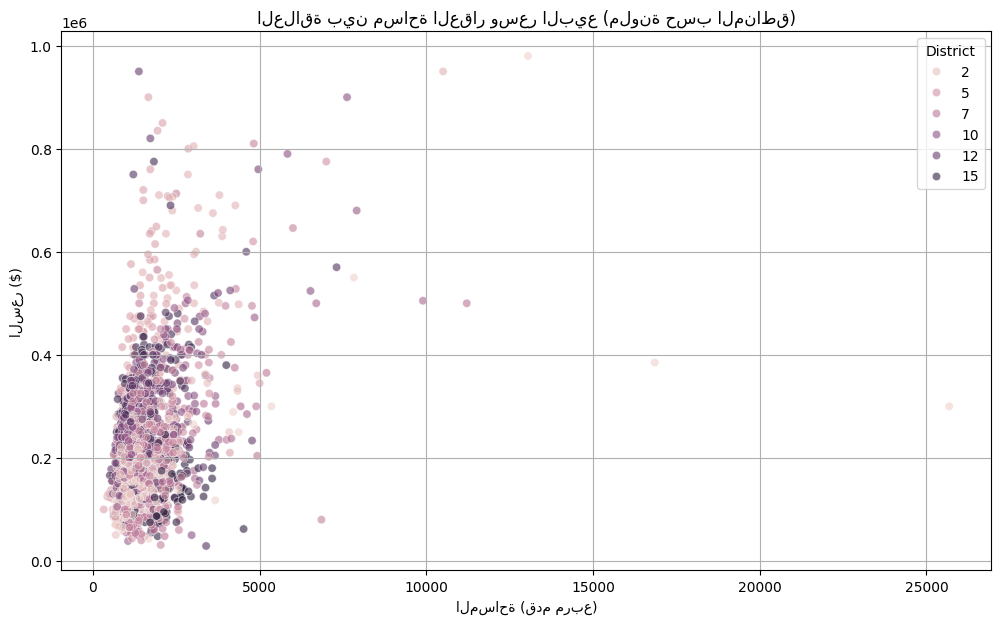

In [19]:
# رسم العلاقة بين المساحة والسعر
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_final, x='FinishedSqft', y='Sale_price', hue='District', alpha=0.6)
plt.title('العلاقة بين مساحة العقار وسعر البيع (ملونة حسب المناطق)')
plt.xlabel('المساحة (قدم مربع)')
plt.ylabel('السعر ($)')
plt.grid(True)
plt.show()

In [20]:
pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# تحديد المتغير المستقل (المساحة) والمتغير التابع (السعر)
X = df_final[['FinishedSqft']] 
y = df_final['Sale_price']

# تقسيم البيانات: 80% للتدريب و 20% لاختبار ذكاء النموذج
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("تم تقسيم البيانات بنجاح.. نحن جاهزون للتدريب!")

تم تقسيم البيانات بنجاح.. نحن جاهزون للتدريب!


In [24]:
# حذف الصفوف التي تحتوي على قيم فارغة في الأعمدة المطلوبة فقط
df_final = df_final.dropna(subset=['FinishedSqft', 'Sale_price'])

# الآن نعيد تشغيل النموذج
X = df_final[['FinishedSqft']]
y = df_final['Sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

print("تم حل المشكلة! الدقة هي:", model.score(X_test, y_test))

تم حل المشكلة! الدقة هي: 0.13083794679545413


In [25]:
# إنشاء النموذج وتدريبه
model = LinearRegression()
model.fit(X_train, y_train)

# قياس الدقة
score = model.score(X_test, y_test)
print(f"دقة النموذج (R^2 Score) هي: {score:.2f}")

دقة النموذج (R^2 Score) هي: 0.13


In [26]:
# تجربة التنبؤ بمساحة معينة
house_space = [[2500]] 
predicted_price = model.predict(house_space)

print(f"السعر المتوقع لمنزل بمساحة 2500 قدم مربع هو: ${predicted_price[0]:,.2f}")

السعر المتوقع لمنزل بمساحة 2500 قدم مربع هو: $283,237.21


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
import joblib

# حفظ النموذج في ملف خارجي
joblib.dump(model, 'milwaukee_price_model.pkl')
print("تم حفظ النموذج بنجاح! يمكنك الآن استخدامه في أي تطبيق مستقبلاً.")

تم حفظ النموذج بنجاح! يمكنك الآن استخدامه في أي تطبيق مستقبلاً.


In [28]:
# تحويل المناطق إلى أعمدة رقمية (0 و 1) ليفهمها الذكاء الاصطناعي
df_final_with_districts = pd.get_dummies(df_final, columns=['District'], drop_first=True)

# اختيار المتغيرات الجديدة (المساحة + المناطق)
features = [col for col in df_final_with_districts.columns if 'District_' in col] + ['FinishedSqft']
X_advanced = df_final_with_districts[features]
y_advanced = df_final_with_districts['Sale_price']

# تدريب النموذج المطور
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_advanced, y_advanced, test_size=0.2, random_state=42)
model_advanced = LinearRegression()
model_advanced.fit(X_train_adv, y_train_adv)

print(f"الدقة بعد إضافة 'الموقع': {model_advanced.score(X_test_adv, y_test_adv):.2f}")

الدقة بعد إضافة 'الموقع': 0.47
